## Step: 1 Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_context("notebook", font_scale=1.2)

## Step: 2 Load Dataset

In [2]:
df=pd.read_excel("C:\Dharan\Cheat Sheets\Datasets\Data_Train.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


## Step 3: Convert Date Columns

In [3]:
# Convert first
df["Date_of_Journey"] = pd.to_datetime(
    df["Date_of_Journey"],
    format="%d/%m/%Y"
)

# Then extract features
df["Journey_Day"] = df["Date_of_Journey"].dt.day
df["Journey_Month"] = df["Date_of_Journey"].dt.month

# (Optional) Remove the original date column
df.drop("Date_of_Journey", axis=1, inplace=True)

## Step 4: Choose Target Variable

For this dataset,


''' Target = Price '''

Every analysis should answer one question:

> "How does this feature affect Price?"

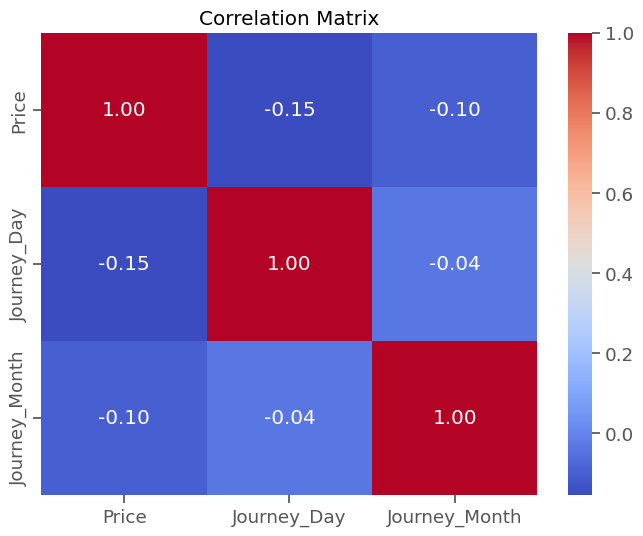

In [4]:
num_cols = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))

sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## 1. Airline vs Price (Boxplot)

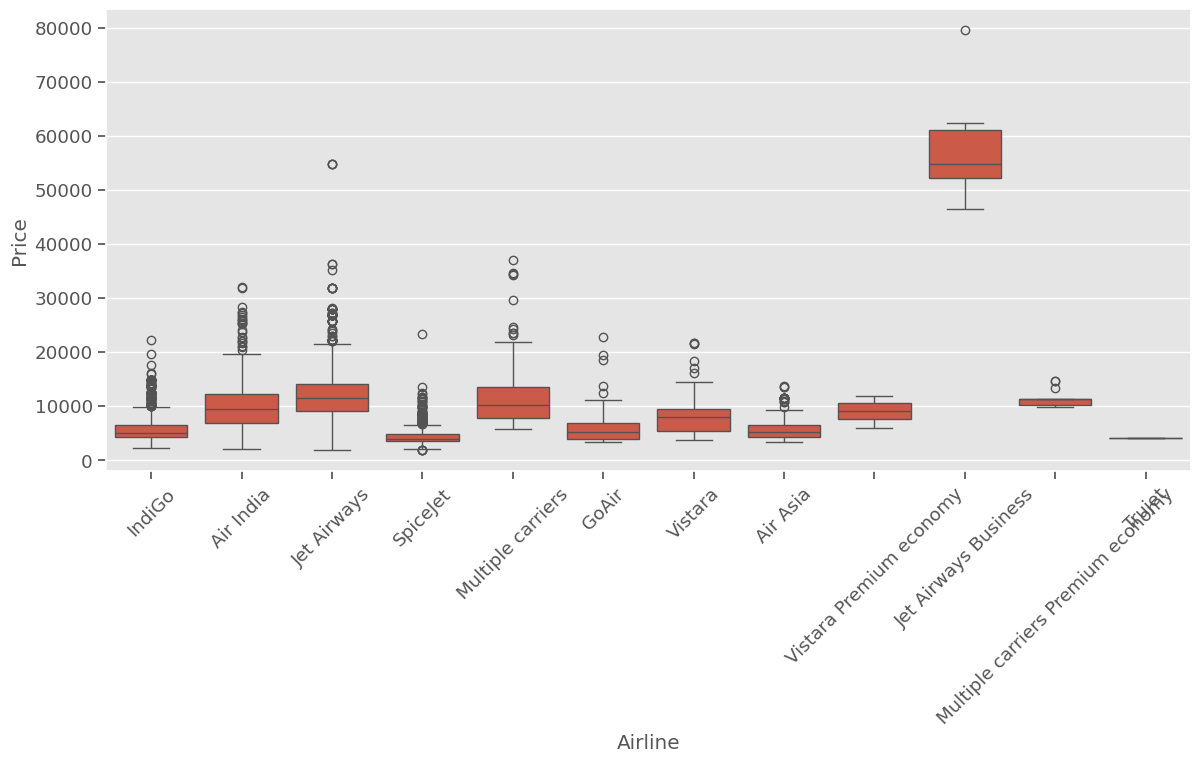

In [6]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="Airline",
    y="Price",
    
)

plt.xticks(rotation=45)
plt.show()

### Observe

> - Which airline is most expensive?
> - Which airline is cheapest?
> - Which airline has the highest variation?

### 2. Source vs Price

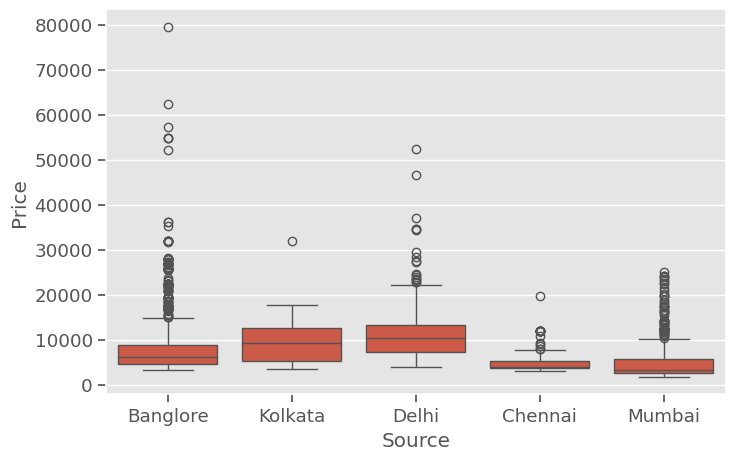

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Source",
    y="Price"
)

plt.show()

### 3. Destination vs Price

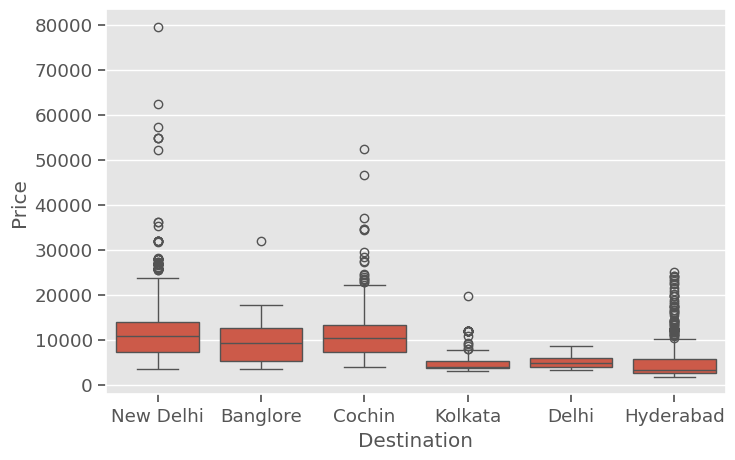

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Destination",
    y="Price"
)

plt.show()

### 4. Total Stops vs Price

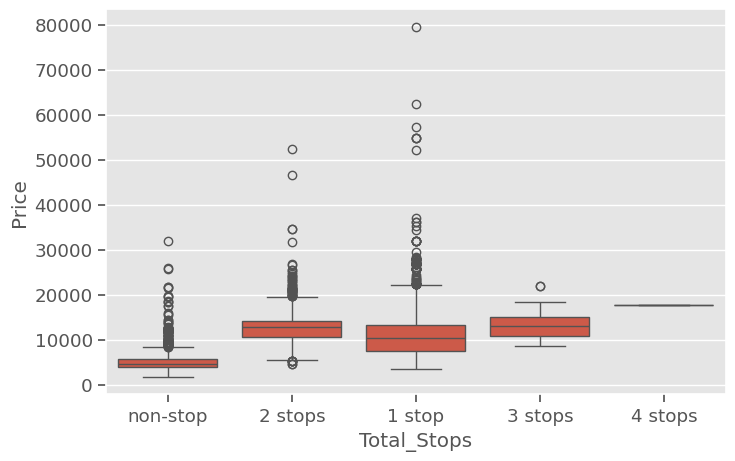

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Total_Stops",
    y="Price"
)

plt.show()

## Numerical vs Numerical

### Duration vs Price

In [13]:
# Extract hours and minutes
hours = df["Duration"].str.extract(r"(\d+)h")[0].fillna(0).astype(int)
minutes = df["Duration"].str.extract(r"(\d+)m")[0].fillna(0).astype(int)

# Convert to total minutes
df["Duration_minutes"] = hours * 60 + minutes

df[["Duration", "Duration_minutes"]].head()

,Duration,Duration_minutes
0,2h 50m,170
1,7h 25m,445
2,19h,1140
3,5h 25m,325
4,4h 45m,285


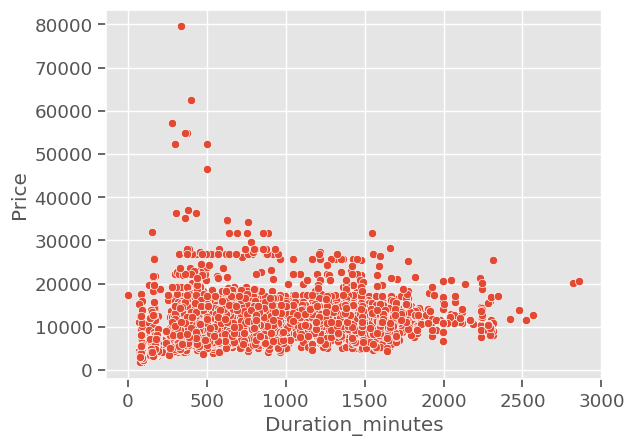

In [15]:
sns.scatterplot(
    data=df,
    x="Duration_minutes",
    y="Price"
)

plt.show()

# Multivariant Analysis

## Airline + Stops + Price

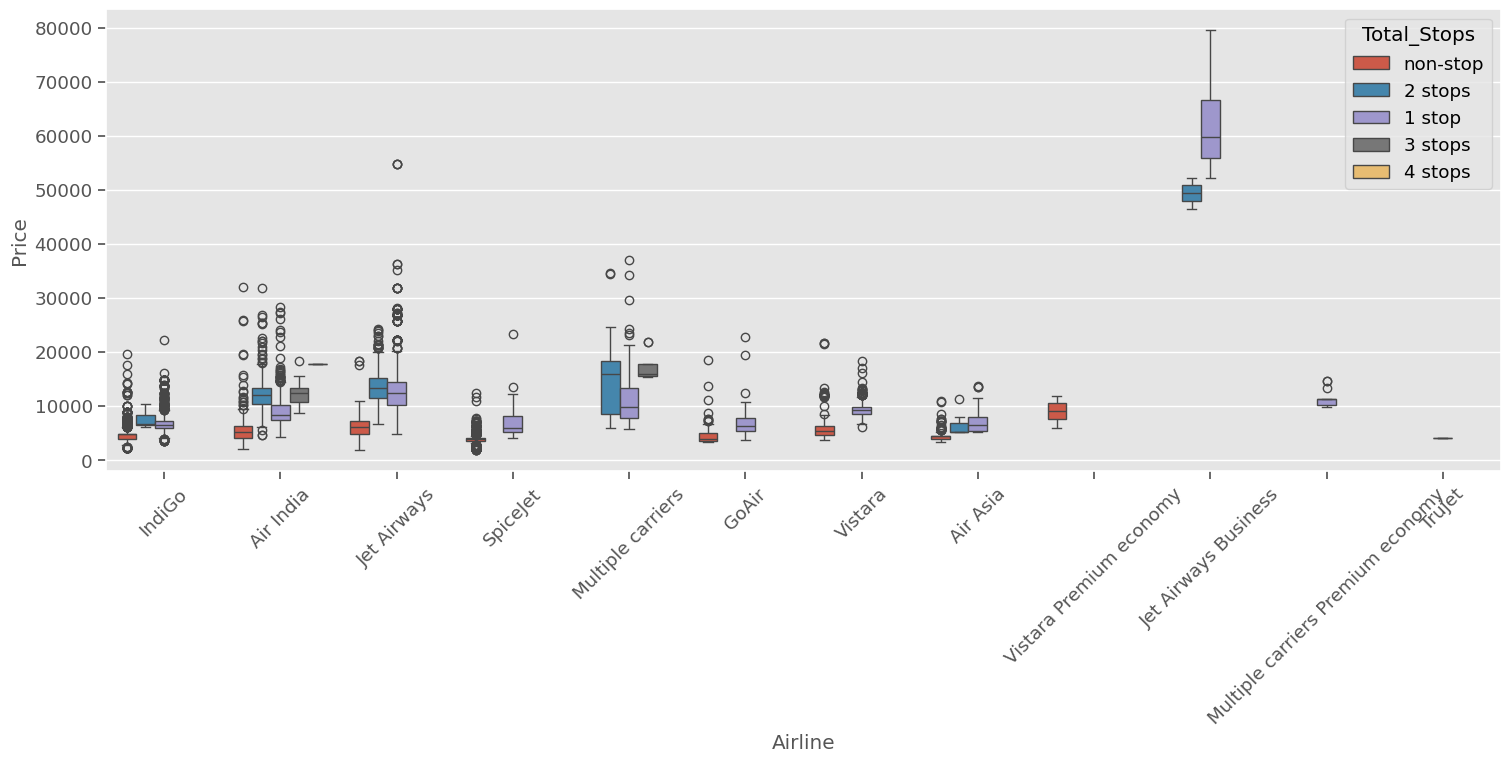

In [26]:
plt.figure(figsize =(18,6))

sns.boxplot(data=df, x='Airline', y = 'Price', hue='Total_Stops')
plt.xticks(rotation=45)
plt.show()

## Minutes travelled + Total Stops + Price

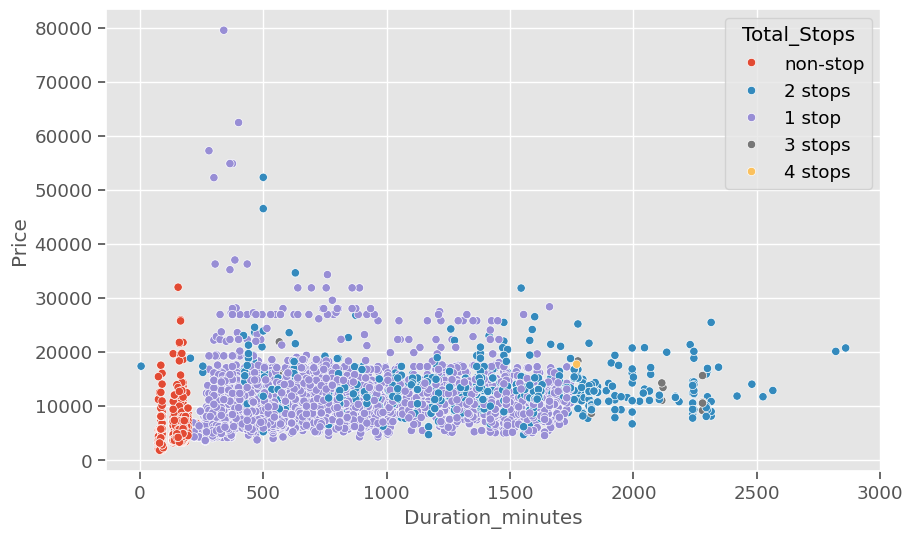

In [43]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Duration_minutes",
    y="Price",
    hue="Total_Stops"
)

plt.show()

> - Does longer duration generally mean higher prices?
> - How do stop counts influence that relationship?